In [ ]:
# use daophot to scale the images based on counts from the same stars
# idea: since the images are both in e/sec and they are very close wavelengths, the stars should have the same value

# - either do this with dao detection and match
# - or do this by scaling the flux using ZP?

In [24]:
import numpy as np
from astropy.io import fits

oiii_data = np.asarray(fits.open("normalized_OIII.fits")[0].data, dtype=np.float32)
oiiic_data = np.asarray(fits.open("aligned_normalized_OIIIC.fits")[0].data, dtype=np.float32)

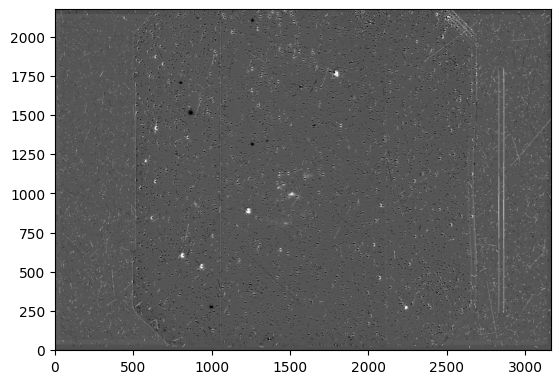

In [26]:
diff = oiii_data - oiiic_data * 0.425
# diff[1050:1060, 1000:1040]

import matplotlib.pyplot as plt
plt.imshow(diff, cmap='gray', origin='lower', vmin=np.percentile(diff,1), vmax=np.percentile(diff,99.5))
plt.show()

fits.writeto("subtracted.fits", diff, overwrite=True)

Shapes: (2174, 3164) (2174, 3164)
OIII FWHM: 7.266971761992677
OIIIC FWHM: 7.505201168487169
Blurred OIII with sigma = 2.3767074778121944
Continuum scale = 0.3988763838043121
Scale scatter = 0.052404031813613534
Number of stars used = 45
Best shift:
dy = 0.25 dx = 1.0 std = 0.004005269


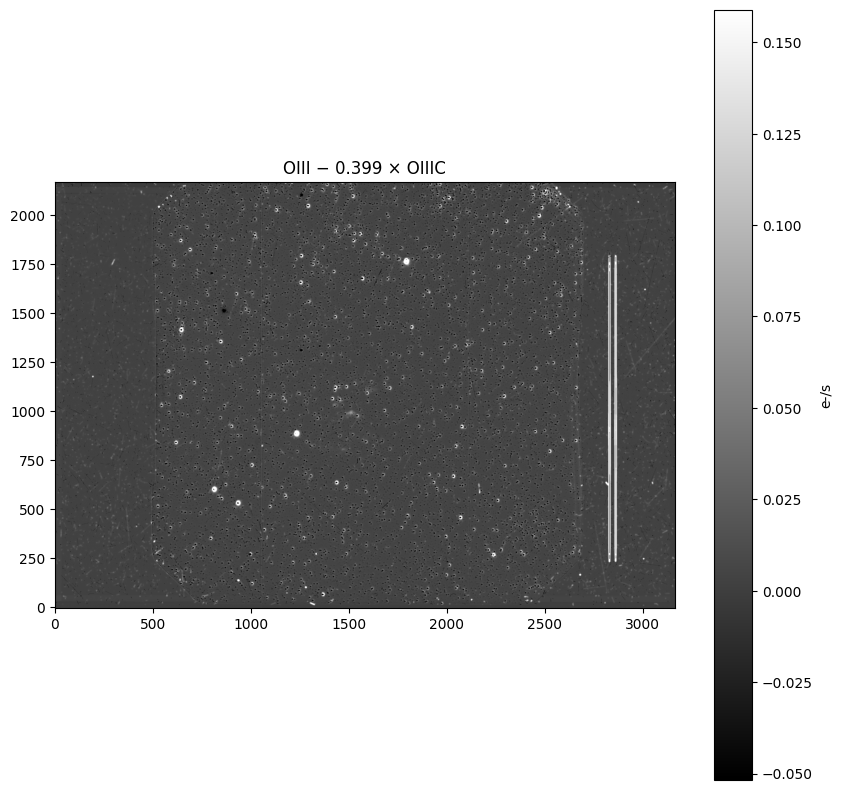

In [22]:
import numpy as np
import matplotlib.pyplot as plt

from astropy.io import fits
from astropy.stats import sigma_clipped_stats
from photutils.detection import DAOStarFinder
from photutils.aperture import CircularAperture, aperture_photometry
from photutils.psf import fit_fwhm
from scipy.ndimage import gaussian_filter, shift


# =========================
# 1. Load normalized images
# =========================

oiii_data = np.asarray(fits.open("normalized_OIII.fits")[0].data, dtype=np.float32)
oiiic_data = np.asarray(fits.open("normalized_OIIIC.fits")[0].data, dtype=np.float32)

# Match shape by cropping OIII to OIIIC
oiii_data = oiii_data[:oiiic_data.shape[0], :oiiic_data.shape[1]]

print("Shapes:", oiii_data.shape, oiiic_data.shape)


# =========================
# 2. Measure FWHM / PSF
# =========================

def measure_fwhm(data, fwhm_guess=5, threshold_sigma=8, nstars=30):
    mean, median, std = sigma_clipped_stats(data)

    finder = DAOStarFinder(fwhm=fwhm_guess, threshold=threshold_sigma * std)
    stars = finder(data - median)

    stars = stars[
        (stars["xcentroid"] > 50) &
        (stars["xcentroid"] < data.shape[1] - 50) &
        (stars["ycentroid"] > 50) &
        (stars["ycentroid"] < data.shape[0] - 50)
    ]

    xy = np.transpose((
        stars["xcentroid"][:nstars],
        stars["ycentroid"][:nstars]
    ))

    fwhms = fit_fwhm(data, xypos=xy, fit_shape=(11, 11))
    return fwhms, np.nanmedian(fwhms)

fwhm_oiii_values, fwhm_oiii = measure_fwhm(oiii_data)
fwhm_oiiic_values, fwhm_oiiic = measure_fwhm(oiiic_data)

print("OIII FWHM:", fwhm_oiii)
print("OIIIC FWHM:", fwhm_oiiic)


fwhm_oiii = 5


# =========================
# 3. PSF match sharper image
# =========================

if fwhm_oiii < fwhm_oiiic:
    sigma_kernel = np.sqrt(fwhm_oiiic**2 - fwhm_oiii**2) / 2.355
    oiii_matched = gaussian_filter(oiii_data, sigma=sigma_kernel)
    oiiic_matched = oiiic_data
    print("Blurred OIII with sigma =", sigma_kernel)

elif fwhm_oiiic < fwhm_oiii:
    sigma_kernel = np.sqrt(fwhm_oiii**2 - fwhm_oiiic**2) / 2.355
    oiii_matched = oiii_data
    oiiic_matched = gaussian_filter(oiiic_data, sigma=sigma_kernel)
    print("Blurred OIIIC with sigma =", sigma_kernel)

else:
    oiii_matched = oiii_data
    oiiic_matched = oiiic_data
    print("No PSF blur needed")


# =========================
# 4. Find continuum scale from stars
# =========================

mean, median, std = sigma_clipped_stats(oiii_matched)

finder = DAOStarFinder(fwhm=fwhm_oiiic, threshold=8 * std)
stars = finder(oiii_matched - median)

stars = stars[
    (stars["xcentroid"] > 50) &
    (stars["xcentroid"] < oiii_matched.shape[1] - 50) &
    (stars["ycentroid"] > 50) &
    (stars["ycentroid"] < oiii_matched.shape[0] - 50)
]

positions = np.transpose((
    stars["xcentroid"][:50],
    stars["ycentroid"][:50]
))

apertures = CircularAperture(positions, r=8)

phot_oiii = aperture_photometry(oiii_matched, apertures)
phot_oiiic = aperture_photometry(oiiic_matched, apertures)

ratios = phot_oiii["aperture_sum"] / phot_oiiic["aperture_sum"]
ratios = np.asarray(ratios)
ratios = ratios[np.isfinite(ratios)]
ratios = ratios[(ratios > 0.25) & (ratios < 0.65)]

scale = np.median(ratios)

print("Continuum scale =", scale)
print("Scale scatter =", np.std(ratios))
print("Number of stars used =", len(ratios))


# =========================
# 5. Optional subpixel shift test
# =========================

best = None

for dy in np.arange(-1.0, 1.01, 0.25):
    for dx in np.arange(-1.0, 1.01, 0.25):
        shifted = shift(oiiic_matched, shift=(dy, dx), order=3, mode="nearest")
        diff_test = oiii_matched - scale * shifted
        mean, median, std = sigma_clipped_stats(diff_test)

        if best is None or std < best[0]:
            best = (std, dy, dx, median)

best_std, best_dy, best_dx, best_median = best

print("Best shift:")
print("dy =", best_dy, "dx =", best_dx, "std =", best_std)

oiiic_final = shift(
    oiiic_matched,
    shift=(best_dy, best_dx),
    order=3,
    mode="nearest"
)


# =========================
# 6. Final subtraction
# =========================

diff_final = oiii_matched - scale * oiiic_final


# =========================
# 7. Plot final image
# =========================

plt.figure(figsize=(10, 10))
plt.imshow(
    diff_final,
    cmap="gray",
    origin="lower",
    vmin=np.nanpercentile(diff_final, 1),
    vmax=np.nanpercentile(diff_final, 99.5)
)
plt.title(f"OIII − {scale:.3f} × OIIIC")
plt.colorbar(label="e-/s")
plt.show()


# =========================
# 8. Save FITS
# =========================

# fits.writeto(
#     "OIII_minus_scaled_OIIIC_final.fits",
#     diff_final,
#     overwrite=True
# )